## Kaggle Problem for Bank dataset.
    * Given a set of variables the problem is to out with the probability of a Term Deposit for a customer.
    * Implemented using XGBOOST
   

In [3]:
import numpy as np
import pandas as pd
import warnings
import datetime
import xgboost as xgb
import seaborn as sns
import itertools
import datetime
import sys
import os
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
%matplotlib inline
warnings.filterwarnings("ignore")




In [4]:
# Load the dataset for Bank Dataset
MyData = pd.read_csv(r'..\..\data\kaggle_bankdata_train.csv') 
MyData.shape


(750000, 18)

In [5]:
MyData.head(7)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
5,5,24,admin.,single,secondary,no,1882,yes,no,cellular,20,apr,1010,3,-1,0,unknown,0
6,6,39,blue-collar,married,secondary,no,0,no,no,telephone,21,nov,90,1,-1,0,unknown,0


In [6]:
MyData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [7]:
MyData.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [8]:
MyData.describe

<bound method NDFrame.describe of             id  age          job   marital  education default  balance  \
0            0   42   technician   married  secondary      no        7   
1            1   38  blue-collar   married  secondary      no      514   
2            2   36  blue-collar   married  secondary      no      602   
3            3   27      student    single  secondary      no       34   
4            4   26   technician   married  secondary      no      889   
...        ...  ...          ...       ...        ...     ...      ...   
749995  749995   29     services    single  secondary      no     1282   
749996  749996   69      retired  divorced   tertiary      no      631   
749997  749997   50  blue-collar   married  secondary      no      217   
749998  749998   32   technician   married  secondary      no     -274   
749999  749999   42   technician   married  secondary      no     1559   

       housing loan   contact  day month  duration  campaign  pdays  previous

In [9]:
# First, let's check the actual column names in the DataFrame
print(MyData.columns)

# Then use the correct column names
# Option 1: If column names are the same but with different capitalization or spacing
My_data_columns = ['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome']
independent_variables = ['age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome']  # Adjust based on actual column names

# Option 2: If columns have completely different names, replace with actual column names
# independent_variables = ["actual_column_1", "actual_column_2", ...]

# Correct syntax for selecting multiple columns - use double square brackets
X = MyData[My_data_columns]
       
y = MyData["y"]  # Adjust if "y" is named differently

# Alternative approach using the independent_variables list
# X = MyData[independent_variables]
# y = MyData["y"]

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')


In [10]:
X.head(5)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown


In [11]:
X.drop(['day', 'month'], axis=1)

,id,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome
0,0,42,technician,married,secondary,no,7,no,no,cellular,117,3,-1,0,unknown
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,185,1,-1,0,unknown
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,111,2,-1,0,unknown
3,3,27,student,single,secondary,no,34,yes,no,unknown,10,2,-1,0,unknown
4,4,26,technician,married,secondary,no,889,yes,no,cellular,902,1,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,29,services,single,secondary,no,1282,no,yes,unknown,1006,2,-1,0,unknown
749996,749996,69,retired,divorced,tertiary,no,631,no,no,cellular,87,1,-1,0,unknown
749997,749997,50,blue-collar,married,secondary,no,217,yes,no,cellular,113,1,-1,0,unknown
749998,749998,32,technician,married,secondary,no,-274,no,no,cellular,108,6,-1,0,unknown


In [12]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print("Train:", len(X_train))  # Changed 'length' to 'len' which is the correct Python function to get length


(600000, 17) (600000,)
(150000, 17) (150000,)
Train: 600000


In [13]:
X_train.head(5)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
282732,282732,59,blue-collar,divorced,primary,no,-232,no,yes,cellular,9,jul,101,1,-1,0,unknown
438460,438460,31,blue-collar,married,secondary,no,1423,yes,no,unknown,20,jun,9,37,-1,0,unknown
238284,238284,50,blue-collar,divorced,secondary,no,1679,yes,no,cellular,24,jul,603,1,-1,0,unknown
335669,335669,53,blue-collar,married,unknown,no,0,no,no,cellular,21,aug,102,4,-1,0,unknown
683451,683451,30,technician,single,secondary,no,35,no,no,cellular,22,aug,431,2,-1,0,unknown


In [14]:
# Approach 2: Label encoding
X_train_le = X_train.copy()
X_val_le = X_val.copy()
X_train_le = X_train_le[independent_variables]
X_val_le   = X_val_le[independent_variables]
le_dict = {}
for col in ['job', 'marital','education','default','housing','loan','contact','poutcome']:
    le = LabelEncoder()
    X_train_le[col] = le.fit_transform(X_train[col])
    X_val_le[col] = le.transform(X_val[col])
    le_dict[col] = le

# Train with label encoded features
model_le = xgb.XGBClassifier()
#model_le = xgb.XGBClassifier(objective="binary:logistic",
#                               eval_metric=['logloss'],
#                               early_stopping_rounds=10)
model_le.fit(X_train_le, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_pred = model_le.predict(X_val_le)
len(model_le.predict(X_val_le))

150000

In [16]:
y_pred_df = pd.DataFrame({
    'id': X_val['id'].reset_index(drop=True),
    'y': pd.Series(y_pred).reset_index(drop=True)
})

In [17]:
y_pred_df.head(5)

,id,y
0,541330,0
1,126360,0
2,98867,0
3,59822,0
4,525026,1


In [18]:
# Count distinct values in column Y
distinct_count = y_pred_df['y'].value_counts()
print(distinct_count)

# If you just want the number of distinct values
num_distinct = y_pred_df['y'].nunique()
print(f"Number of distinct values: {num_distinct}")

y
0    135125
1     14875
Name: count, dtype: int64
Number of distinct values: 2


Accuracy: 0.9259
Accuracy: 92.59%
Accuracy (from confusion matrix): 0.9259
Accuracy (from confusion matrix): 92.59%


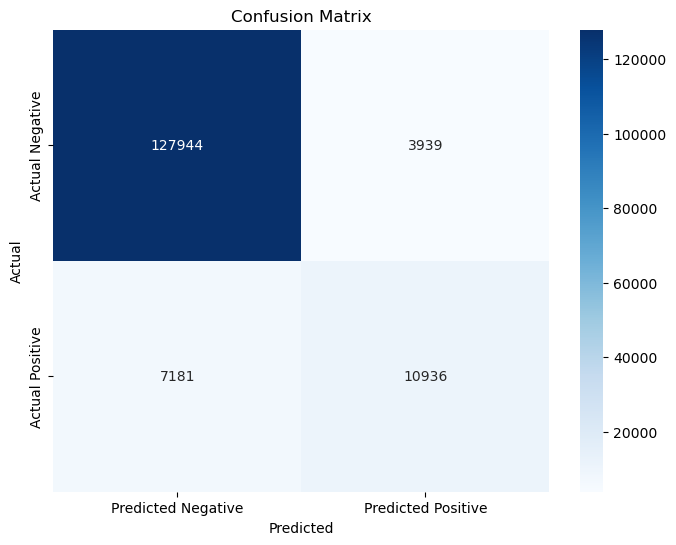

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Get confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Calculate accuracy manually from confusion matrix
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    accuracy_from_cm = (tp + tn) / (tp + tn + fp + fn)
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm:.4f}")
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm*100:.2f}%")

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# For multi-class problems, you might want to normalize the confusion matrix
if cm.shape[0] > 2:
    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot normalized confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Normalized Confusion Matrix')
    plt.show()

In [20]:
# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Alternative method using confusion matrix
from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Calculate accuracy manually from confusion matrix
# For binary classification:
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    accuracy_from_cm = (tp + tn) / (tp + tn + fp + fn)
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm:.4f}")
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm*100:.2f}%")

Accuracy: 0.9259
Accuracy: 92.59%
Accuracy (from confusion matrix): 0.9259
Accuracy (from confusion matrix): 92.59%


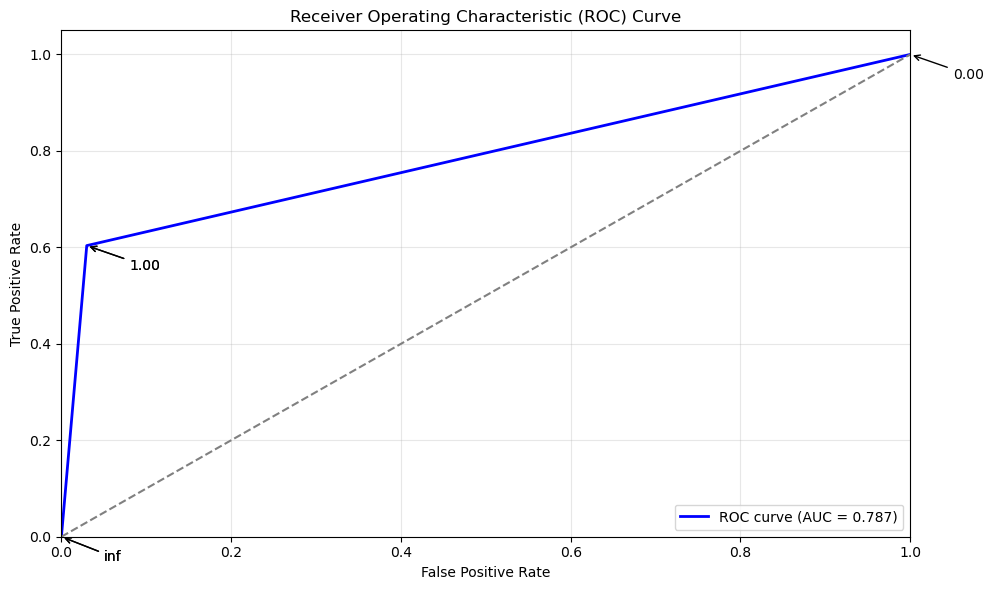

AUC: 0.7869


In [21]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get predicted probabilities for the positive class
# For binary classification, we need the probability of the positive class (class 1)
# y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

# Calculate AUC
roc_auc = auc(fpr, tpr)
# Alternative: roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Add some threshold annotations
# Select a few thresholds to annotate
threshold_indices = np.linspace(0, len(thresholds) - 1, 5, dtype=int)
for i in threshold_indices:
    plt.annotate(f'{thresholds[i]:.2f}', 
                 xy=(fpr[i], tpr[i]), 
                 xytext=(fpr[i]+0.05, tpr[i]-0.05),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3'))

plt.tight_layout()
plt.show()

# Print AUC value
print(f"AUC: {roc_auc:.4f}")

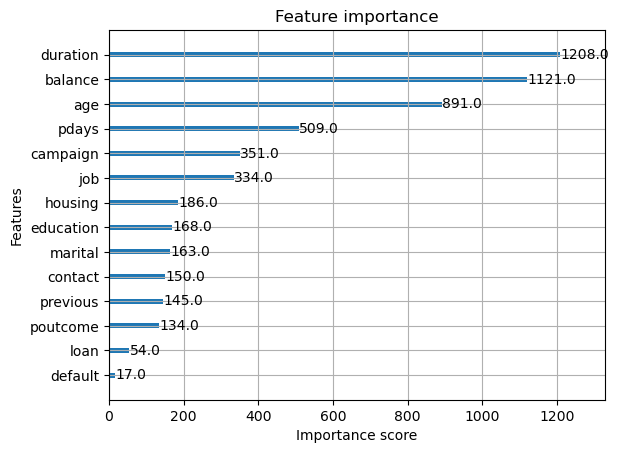

In [22]:
xgb.plot_importance(model_le)
plt.show()

In [23]:
probabilities = model_le.predict_proba(X_val_le)

In [24]:
val_probabilities_df = pd.DataFrame({
    'id': X_train['id'].reset_index(drop=True),
    # Extract the probability for class 1 (second column)
    'y': pd.Series(probabilities[:, 1]).reset_index(drop=True)  # Using column index 1 for positive class probability
    # Alternatively, if you want both probabilities:
    # 'y_class0': pd.Series(probabilities[:, 0]).reset_index(drop=True),
    # 'y_class1': pd.Series(probabilities[:, 1]).reset_index(drop=True)
})
val_probabilities_df.head(10)

,id,y
0,282732,0.001157
1,438460,0.109507
2,238284,0.085014
3,335669,0.000720
4,683451,0.986858
5,573256,0.000874
6,644771,0.400484
7,280112,0.000218
8,602891,0.018696
9,675344,0.000513


In [25]:
# Load the test dataset for Bank Dataset
MyData_test_df = pd.read_csv(r'..\..\data\kaggle_bankdata_test.csv') 
MyData_test_df.shape

(250000, 17)

In [26]:
MyData_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         250000 non-null  int64 
 1   age        250000 non-null  int64 
 2   job        250000 non-null  object
 3   marital    250000 non-null  object
 4   education  250000 non-null  object
 5   default    250000 non-null  object
 6   balance    250000 non-null  int64 
 7   housing    250000 non-null  object
 8   loan       250000 non-null  object
 9   contact    250000 non-null  object
 10  day        250000 non-null  int64 
 11  month      250000 non-null  object
 12  duration   250000 non-null  int64 
 13  campaign   250000 non-null  int64 
 14  pdays      250000 non-null  int64 
 15  previous   250000 non-null  int64 
 16  poutcome   250000 non-null  object
dtypes: int64(8), object(9)
memory usage: 32.4+ MB


In [27]:
MyData_test_df.describe

<bound method NDFrame.describe of             id  age            job  marital  education default  balance  \
0       750000   32    blue-collar  married  secondary      no     1397   
1       750001   44     management  married   tertiary      no       23   
2       750002   36  self-employed  married    primary      no       46   
3       750003   58    blue-collar  married  secondary      no    -1380   
4       750004   28     technician   single  secondary      no     1950   
...        ...  ...            ...      ...        ...     ...      ...   
249995  999995   43     management  married   tertiary      no        0   
249996  999996   40       services  married    unknown      no      522   
249997  999997   63        retired  married    primary      no       33   
249998  999998   50    blue-collar  married    primary      no     2629   
249999  999999   29        student   single   tertiary      no      722   

       housing loan   contact  day month  duration  campaign  pda

In [28]:
X_test = MyData_test_df[My_data_columns]
X_test.head(5)       
#y = MyData_test_df["y"]  # Adjust if "y" is named differently

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [29]:
X_test_le = X_test.copy()
X_test_le = X_test_le[independent_variables]
le_dict = {}

# Create and fit a separate label encoder for each categorical column
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']:
    # Create a new label encoder for each column
    le_dict[col] = LabelEncoder()
    
    # Combine training and test data values to fit the encoder on all possible values
    # This ensures the encoder knows about all categories
    all_values = pd.concat([X_train[col], X_test[col]]).unique()
    le_dict[col].fit(all_values)
    
    # Transform the test data using the properly fitted encoder
    X_test_le[col] = le_dict[col].transform(X_test[col])

In [30]:
X_test_le.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome
0,32,1,1,1,0,1397,1,0,2,224,1,-1,0,3
1,44,4,1,2,0,23,1,0,0,586,2,-1,0,3
2,36,6,1,0,0,46,1,1,0,111,2,-1,0,3
3,58,1,1,1,0,-1380,1,1,2,125,1,-1,0,3
4,28,9,2,1,0,1950,1,0,0,181,1,-1,0,3


In [31]:
y_test = model_le.predict(X_test_le)

In [32]:
submission_df = pd.DataFrame({
    'id': X_test['id'].reset_index(drop=True),
    'y': pd.Series(y_test).reset_index(drop=True)
})

In [33]:
submission_df.head(5)

,id,y
0,750000,0
1,750001,0
2,750002,0
3,750003,0
4,750004,0


In [34]:
# Count distinct values in column Y
distinct_count = submission_df['y'].value_counts()
print(distinct_count)

# If you just want the number of distinct values
num_distinct = submission_df['y'].nunique()
print(f"Number of distinct values: {num_distinct}")

y
0    224939
1     25061
Name: count, dtype: int64
Number of distinct values: 2


In [35]:
test_probabilities = model_le.predict_proba(X_test_le)


In [36]:
submission_probabilities_df = pd.DataFrame({
    'id': X_test['id'].reset_index(drop=True),
    # Extract the probability for class 1 (second column)
    'y': pd.Series(test_probabilities[:, 1]).reset_index(drop=True)  # Using column index 1 for positive class probability
    # Alternatively, if you want both probabilities:
    # 'y_class0': pd.Series(probabilities[:, 0]).reset_index(drop=True),
    # 'y_class1': pd.Series(probabilities[:, 1]).reset_index(drop=True)
})
submission_probabilities_df.head(10)

,id,y
0,750000,0.002282
1,750001,0.094907
2,750002,0.000195
3,750003,0.000170
4,750004,0.047493
5,750005,0.004697
6,750006,0.564768
7,750007,0.497460
8,750008,0.004267
9,750009,0.291782


In [37]:
submission_probabilities_df.to_csv(r'..\..\results\submission.csv', index=False)
print("CSV file has been created successfully!")

CSV file has been created successfully!


In [38]:
# Define the threshold as a variable
threshold = 0.5

# Filter the DataFrame to show only rows where y >= threshold
filtered_df = submission_probabilities_df[submission_probabilities_df['y'] >= threshold]

# Display all filtered rows
print(f"Rows where y >= {threshold}:")
display(filtered_df)

# Count the total number of rows where y >= threshold
count = len(filtered_df)
print(f"\nTotal number of rows where y >= {threshold}: {count}")

# Optional: Calculate the percentage of rows that meet the condition
percentage = (count / len(submission_probabilities_df)) * 100
print(f"Percentage of rows where y >= {threshold}: {percentage:.2f}%")

Rows where y >= 0.5:


,id,y
6,750006,0.564768
26,750026,0.534242
29,750029,0.973521
34,750034,0.513144
48,750048,0.809548
...,...,...
249980,999980,0.768415
249982,999982,0.644281
249986,999986,0.628203
249994,999994,0.563243



Total number of rows where y >= 0.5: 25061
Percentage of rows where y >= 0.5: 10.02%
